# 120 years of Olympic medalists

Exploring trends in Olympic medalists from 1896–2016

<div style="text-align: center;">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5c/Olympic_rings_without_rims.svg/2560px-Olympic_rings_without_rims.svg.png" alt="The Olympic Rings" width="280"/>
</div>

**Author:** Maurice Colbert Jr.

**Tools:** Python · pandas · matplotlib &nbsp;&nbsp; **Dataset:** 39,783 Olympic medal records, 1896–2016

---

## Project Overview

This notebook is an exploratory analysis of Olympic medalists spanning 120 years.
The brief was newsroom-style: explore the data, then pitch a story a general
audience would actually read. There was no predefined question, so most of the
work was deciding which question was worth asking.

Three questions structured the pass:

1. Which countries have dominated the Olympic podium over time?
2. How has the age of medalists shifted — and what does a 63-year range actually mean?
3. How has women's participation in the Olympics evolved?

Each row is one athlete-event-medal: country, age, sport, event, and medal type.

### Approach

I followed the standard data analytics cycle. Each section below is one phase of
that process. The Insights section at the end is where the three questions stop
being separate and become one story.

## 1. Setup

Import pandas for the tables and matplotlib for charts that GitHub can render
without a live kernel, then load the CSV.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

df = pd.read_csv("data/olympics.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Years covered: {df['Year'].min()} – {df['Year'].max()}")
df.head()

Dataset shape: 39,783 rows × 16 columns
Years covered: 1896 – 2016


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region
0,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark
1,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland
2,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland
3,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze,Finland
4,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland


## 2. Prepare: inspect and clean the data

Before answering anything I need to know what is missing, what is duplicated,
and whether the country column is actually a country column.

In [2]:
df.isna().sum()

ID           0
Name         0
Sex          0
Age        732
Height    8711
Weight    9327
Team         0
NOC          0
Games        0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
region       9
dtype: int64

Observations on missing data:

- `Age`, `Height`, and `Weight` have missing values. That is common in historical
  records, but I do not yet know whether the holes are random or clustered in
  early Games.
- `region` has 9 missing values (< 0.03%).

The reflex is to drop incomplete rows or fill them with a mean. Before doing
either I checked *where* the nulls sit, because missing-at-random and
missing-by-era have completely different consequences.

In [3]:
df["era"] = pd.cut(
    df.Year,
    [1895, 1936, 1959, 1979, 2016],
    labels=["1896–1936", "1937–1959", "1960–1979", "1980–2016"],
)
missing_by_era = (
    df.groupby("era", observed=True)[["Age", "Height", "Weight"]]
    .apply(lambda d: 100 * d.isna().mean())
    .round(1)
)
missing_by_era

,Age,Height,Weight
era,,,
1896–1936,8.3,75.4,81.3
1937–1959,1.0,62.7,62.9
1960–1979,0.1,2.0,2.6
1980–2016,0.0,1.7,2.1


The missingness is almost entirely historical: **75.4% of 1896–1936 records have
no height**, against 1.7% after 1980. Early organizers simply did not record body
measurements.

That kills a tempting analysis — "athletes have gotten bigger over time" —
because any early-era average would come from the unrepresentative minority who
happened to be measured. Rules for the rest of this notebook:

- Leave the nulls in place (pandas already excludes them from aggregations)
  rather than imputing values I cannot justify.
- Filter out missing `Age` only when computing age statistics.
- Do not use `Height` or `Weight` across eras. If I report them at all, it is
  inside a single recent Games, with the sample size stated.

In [4]:
print(f"Unique values — Team: {df.Team.nunique()}, NOC: {df.NOC.nunique()}, "
      f"region: {df.region.nunique()}")
print(f"Team disagrees with region on {100 * (df.Team != df.region).mean():.1f}% of rows\n")
print("Examples of what Team actually contains:")
print(df.loc[df.Team.str.contains("/", na=False), "Team"].value_counts().head(5).to_string())

Unique values — Team: 498, NOC: 149, region: 136
Team disagrees with region on 37.1% of rows

Examples of what Team actually contains:
Team
Pistoja/Firenze          9
Denmark/Sweden           6
Barion/Bari-2            3
Great Britain/Germany    2
United States/France     2


`Team` is not a country column. It holds 498 distinct values against 136
countries, and the extras are club names (`Pistoja/Firenze`), mixed-nationality
crews (`Denmark/Sweden`), and numbered squads (`Bari-2`). Grouping by it would
split one country's medals across many labels. I drop it and standardize on
`NOC` / `region`.

In [5]:
df = (
    df.drop(columns=["Team"])
    .rename(columns={"NOC": "CountryCode", "region": "Country"})
)

missing_codes = sorted(set(df.CountryCode[df.Country.isna()]))
print(f"Rows with no Country: {df.Country.isna().sum()} (codes: {missing_codes})")
df.loc[df.Country.isna(), "Country"] = "Singapore"  # SGP is unambiguous
print(f"Remaining nulls in Country: {df.Country.isna().sum()}")

duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df = df.drop_duplicates()
print(f"Cleaned dataset: {df.shape[0]:,} rows")

Rows with no Country: 9 (codes: ['SGP'])
Remaining nulls in Country: 0
Duplicate rows found: 11
Cleaned dataset: 39,772 rows


Nine rows had a null country. All nine carry the code `SGP`, which is
unambiguously Singapore, so filling them is a repair, not a guess — I would
rather keep nine medalists than drop them because a label was blank.

The dataset is now ready for the three questions.

## 3. Analyze

### Question 1: Which countries have won the most medals?

A medal table is the conventional first cut, and it is the right place to start
as long as I remember what the grain is: one row per athlete-event-medal, so
team sports are over-weighted relative to individual events.

In [6]:
medal_table = (
    df.groupby("Country")
    .agg(total=("Medal", "size"),
         gold=("Medal", lambda s: (s == "Gold").sum()))
    .nlargest(10, "total")
)
medal_table["gold_pct"] = (100 * medal_table.gold / medal_table.total).round(1)
medal_table

,total,gold,gold_pct
Country,,,
USA,5637,2638,46.8
Russia,3947,1599,40.5
Germany,3756,1301,34.6
UK,2067,677,32.8
France,1767,499,28.2
Italy,1637,575,35.1
Sweden,1536,479,31.2
Canada,1352,463,34.2
Australia,1349,368,27.3


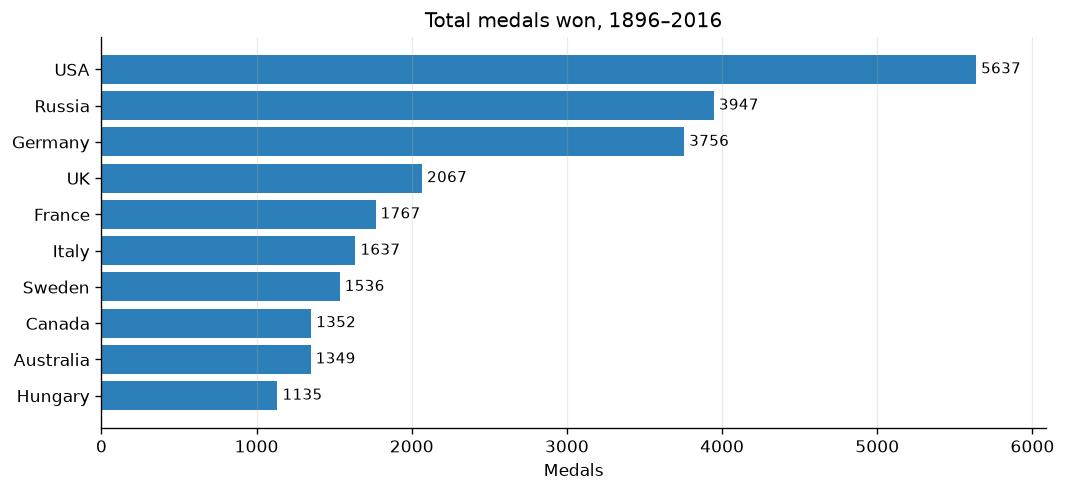

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
top = medal_table.sort_values("total")
ax.barh(top.index, top.total, color="#2c7fb8")
ax.bar_label(ax.containers[0], fmt="%d", padding=3, fontsize=9)
ax.set_title("Total medals won, 1896–2016")
ax.set_xlabel("Medals")
ax.grid(axis="y", visible=False)
ax.margins(x=0.08)
fig.tight_layout()
fig.savefig(FIGURES / "02_medal_table.png", bbox_inches="tight")
plt.show()

**Takeaway.** The USA leads with 5,637 medals and the highest gold conversion
of the top ten at 46.8%. Russia and Germany follow. That ranking is familiar
and, by itself, not a story — it is a baseline. The interesting numbers in this
dataset are the ones that do not fit a modern picture of an elite athlete.

### Question 2: How has the age of medalists shifted?

I am not asking this to produce a mean-age chart. I am asking it because the
first descriptive pass showed a 63-year range: a 10-year-old medalist and a
73-year-old medalist. That range cannot both be explained by the modern
picture of an elite athlete, so the outliers are the lead.

In [8]:
age_known = df.dropna(subset=["Age"])
print("Youngest medalists:")
print(age_known.nsmallest(3, "Age")[["Name", "Age", "Year", "Sport", "Medal", "Country"]]
      .to_string(index=False))
print("\nTen oldest medalists:")
oldest = age_known.nlargest(10, "Age")
print(oldest[["Name", "Age", "Year", "Sport", "Medal", "Country"]].to_string(index=False))
print("\nSports among the ten oldest:")
print(oldest.Sport.value_counts().to_string())

Youngest medalists:
              Name  Age  Year      Sport  Medal Country
Dimitrios Loundras 10.0  1896 Gymnastics Bronze  Greece
  Luigina Giavotti 11.0  1928 Gymnastics Silver   Italy
   Carla Marangoni 12.0  1928 Gymnastics Silver   Italy

Ten oldest medalists:
                                         Name  Age  Year            Sport  Medal     Country
John (Herbert Crawford-) Copley (Williamson-) 73.0  1948 Art Competitions Silver          UK
                                   Jozu Dupon 72.0  1936 Art Competitions Bronze     Belgium
                            Oscar Gomer Swahn 72.0  1920         Shooting Silver      Sweden
                       Charles William Martin 71.0  1900          Sailing Silver      France
                       Charles William Martin 71.0  1900          Sailing Bronze      France
                      Letitia Marion Hamilton 69.0  1948 Art Competitions Bronze     Ireland
                                 Oskar Thiede 69.0  1948 Art Competitions Silver  

#### Were the oldest medalists athletes?

Five of the ten oldest medalists in Olympic history won in **Art Competitions**.
Before treating that as a curiosity I need to know whether art was a real
programme or a handful of one-offs.

In [9]:
art = df[df.Sport == "Art Competitions"]
print(f"Art Competition medals: {len(art)}")
print(f"Years contested:        {[int(y) for y in sorted(art.Year.unique())]}")
print(f"Mean age of medalist:   {art.Age.mean():.1f}  (all sports: {df.Age.mean():.1f})")
print(f"Share of all medals awarded 1912–1948: "
      f"{100 * len(art) / len(df[df.Year.between(1912, 1948)]):.1f}%")

over_60 = age_known[age_known.Age >= 60]
print(f"\nMedalists aged 60+: {len(over_60)}")
print(over_60.Sport.value_counts().head(5).to_string())

Art Competition medals: 156
Years contested:        [1912, 1920, 1924, 1928, 1932, 1936, 1948]
Mean age of medalist:   42.3  (all sports: 25.9)
Share of all medals awarded 1912–1948: 2.3%

Medalists aged 60+: 42
Sport
Art Competitions    11
Shooting            11
Archery             11
Sailing              4
Equestrianism        4


**Takeaway.** Art Competitions were a real Olympic programme: 156 medals across
seven Games from 1912 to 1948, mean medalist age 42.3 against 25.9 overall. The
category was abolished after 1948 and never returned. The age "trend" is not
mainly athletes getting younger — it is the Games stopping the event that
produced old medalists.

### Question 3: How has women's participation evolved?

If the early Olympics were a different kind of event, not a smaller version of
today's Games, that shift should show up in more than the art medals. Women's
share of medalists is the cleanest independent check. Event count and country
count are a third.

In [10]:
def by_year_for(season: str) -> pd.DataFrame:
    """Per-Games summary for one season.

    Summer and Winter must be tracked separately. A Winter Games has roughly a
    third as many events as a Summer Games, so combining them into one series
    produces a sawtooth that looks like the programme repeatedly shrinking and
    expanding rather than a trend.
    """
    subset = df[df.Season == season]
    return pd.DataFrame({
        "events": subset.groupby("Year").Event.nunique(),
        "countries": subset.groupby("Year").Country.nunique(),
        "female_pct": subset.groupby("Year").apply(
            lambda d: 100 * (d.Sex == "F").mean(), include_groups=False),
    })


summer = by_year_for("Summer")
winter = by_year_for("Winter")
art_by_year = df[df.Sport == "Art Competitions"].groupby("Year").size()

print("Summer Games:")
print(summer.loc[[1896, 1912, 1936, 1948, 1960, 1984, 2000, 2016]].round(1).to_string())
print("\nWinter Games:")
print(winter.loc[[1924, 1960, 1984, 2014]].round(1).to_string())

Summer Games:
      events  countries  female_pct
Year                               
1896      43         10         0.0
1912     107         19         3.2
1936     143         32         9.6
1948     148         38        11.9
1960     150         44        17.1
1984     221         47        33.5
2000     300         80        43.9
2016     306         86        47.9

Winter Games:
      events  countries  female_pct
Year                               
1924      17         13         4.6
1960      27         14        26.5
1984      39         16        24.3
2014      98         26        44.4


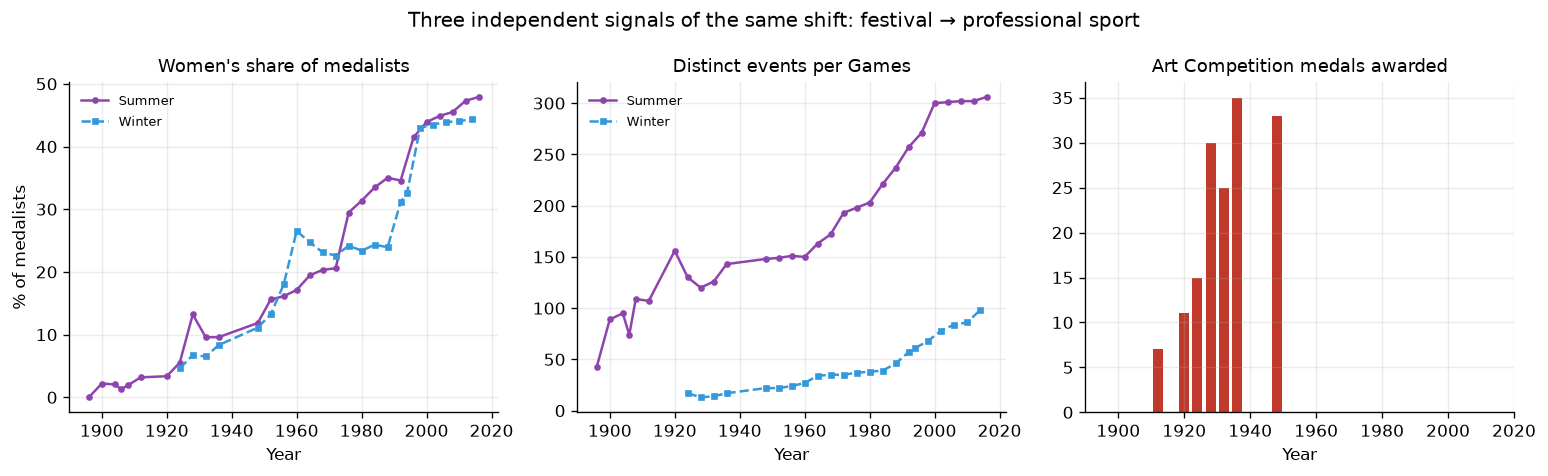

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(summer.index, summer.female_pct, color="#8e44ad", marker="o", markersize=3,
             label="Summer")
axes[0].plot(winter.index, winter.female_pct, color="#3498db", marker="s", markersize=3,
             linestyle="--", label="Winter")
axes[0].set_title("Women's share of medalists", fontsize=11)
axes[0].set_ylabel("% of medalists")
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(summer.index, summer.events, color="#8e44ad", marker="o", markersize=3,
             label="Summer")
axes[1].plot(winter.index, winter.events, color="#3498db", marker="s", markersize=3,
             linestyle="--", label="Winter")
axes[1].set_title("Distinct events per Games", fontsize=11)
axes[1].legend(frameon=False, fontsize=8)

axes[2].bar(art_by_year.index, art_by_year.values, width=3, color="#c0392b")
axes[2].set_title("Art Competition medals awarded", fontsize=11)
axes[2].set_xlim(1890, 2020)

for ax in axes:
    ax.set_xlabel("Year")

fig.suptitle("Three independent signals of the same shift: festival → professional sport",
             fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "01_olympic_transformation.png", bbox_inches="tight")
plt.show()

**Takeaway.** Women's share of medalists goes from 0% in 1896 to 47.9% at the
2016 Summer Games, with Winter following the same trajectory. Events per Summer
Games grow from 43 to 306; countries from 10 to 86. Art medals stop after 1948.
All three move together.

Splitting Summer and Winter matters. Plotting every Games on one line produced
a sawtooth, because a Winter Games has roughly a third the events of a Summer
Games — it looked like the programme was collapsing and recovering rather than
growing.

## 4. Key Insights

### Insight 1 — The medal table is the baseline, not the story

The USA, Russia, and Germany dominate the all-time count. That is expected. The
useful part of Question 1 is what it is *not*: it does not explain a 10-year-old
gold medalist or a 73-year-old one. Country rankings describe volume. They do
not describe what the Games thought was worth awarding.

### Insight 2 — Half of the oldest medalists were not athletes

Five of the ten oldest medalists in Olympic history won for art. 156 medals,
1912–1948, then the category is abolished. The age range is 63 years wide
because the early Games were closer to a cultural festival than to a
professional sports championship.

### Insight 3 — Who the Games are for changed on every axis at once

Women go from 0% to 47.9% of medalists. Events go from 43 to 306. Art
disappears. The Games did not simply get bigger. Their purpose changed — from a
broad celebration of culture and physical life into a professionalized global
sporting competition with near-parity participation.

**Headline if I were reporting this:** *The Olympics used to give medals for
sculpture. What we stopped rewarding says as much as what we started rewarding.*

## 5. Limitations and next steps

- Medal-winning entries only. "47.9% of medalists were women" is not the same
  as 47.9% of competitors.
- Team events award one medal per athlete, so team sports are over-weighted in
  the country table.
- Country labels are modern. The USSR and East Germany make long-run country
  comparisons imperfect.
- Height and weight are only reliable from roughly 1960 onward, which is why
  they stay out of the era comparison.

### Where I would take this next

The IOC's stated reason for ending the art competitions (amateurism rules are
the likely cause, since artists sold their work), and participation data
alongside medal data, so growth in *opportunity* can be distinguished from
growth in *access*.

## How I used AI on this project

I did the analysis and chose the story angle myself. AI was a copilot in two
places:

1. **A second opinion on missing data.** I described the null pattern in `Age`,
   `Height`, and `Weight` and asked whether ignoring them was defensible. The
   useful part of the answer was the reminder to check whether missingness
   correlates with another variable — which is what the era breakdown tests,
   and why I abandoned the cross-era body-size comparison.
2. **Framing the pitch.** I gave the model my findings and asked for ways to
   frame them for a general audience. It suggested leading with the human
   oddity (a 73-year-old sculptor) before the structural argument, which I
   kept. I wrote the pitch itself, and I verified every number in it against
   the notebook.

Notebook structure follows the Global Career Accelerator cleaned-example
cycle (setup → prepare → analyze → insights). The questions, cleaning
decisions, and findings are from my own Milestone 5 work.